<a href="https://colab.research.google.com/github/gechsimxx-design/BCO7006---ASM-4-/blob/kevin/ASM_4_Group_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assessment 4 — House Prices Analytics Solution Modelling Notebook

This notebook is prepared to match the Technical Appendix structure. It explains the main code cells used to load, clean, explore, analyse, model and predict house prices using the Kaggle House Prices dataset.

**How to use:** place `train.csv` and `test.csv` in the same folder as this notebook, then run the cells from top to bottom.

This version includes small Google Colab-safe adjustments, especially for missing values, log transformations, Pearson correlation, heatmap creation and Random Forest training.

## Cell 1: Import libraries and display settings

**What it does:** This cell imports the main Python libraries used for data analysis, visualisation and statistical checking.

**Libraries used:** `numpy` for numerical calculations, `pandas` for tables and data cleaning, `matplotlib` and `seaborn` for charts, `scipy.stats` for Pearson correlation, and `warnings` to hide unnecessary warnings.

**pandas / numpy methods:** `pd.set_option()` changes the pandas display setting so more columns can be shown.

**Loops / conditions:** There are no loops or conditions in this cell.

**Why it matters for the business:** This cell sets up the tools needed to inspect housing data, clean it and identify patterns that help predict house prices.

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 105)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set()

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Cell 2: Set modelling options

**What it does:** This cell sets important options used later in the notebook.

**Libraries used:** No external library is directly used. It creates Python variables.

**pandas / numpy methods:** No pandas or numpy methods are used.

**Loops / conditions:** There are no loops. However, `drop_similar = 1` is used later in an `if` condition to remove similar highly correlated features.

**Explanation:**\
nr_cv = 5 means the notebook will use five-fold cross-validation when testing models.
use_logvals = 1 means the notebook will use log-transformed values.
target = 'SalePrice_Log' sets the prediction target as the log-transformed sale price.
min_val_corr = 0.4 means only features with correlation above 0.4 are treated as strong predictors.
drop_similar = 1 means the notebook will remove some features that repeat similar information.

**Why it matters for the business:** These settings control how strict the model is when selecting useful property features for price prediction.

In [ ]:
nr_cv = 5
use_logvals = 1
target = 'SalePrice_Log'
min_val_corr = 0.4
drop_similar = 1

## Cell 3: Define helper function for model score

**What it does:** This function extracts and prints the best model score, best parameters and best model from a `GridSearchCV` result.

**Libraries used:** `numpy` is used through `np.sqrt()`.

**pandas / numpy methods:** `np.sqrt()` calculates the square root. Because the notebook uses negative mean squared error, `-grid.best_score_` converts it back into a positive value before calculating RMSE.

**Loops / conditions:** There are no loops or conditions.

**Why it matters for the business:** RMSE helps compare prediction accuracy. A lower RMSE means predicted house prices are closer to actual prices.

In [ ]:
def get_best_score(grid):

    best_score = np.sqrt(-grid.best_score_)
    print(best_score)
    print(grid.best_params_)
    print(grid.best_estimator_)

    return best_score

## Cell 4: Define helper function for correlation matrix

**What it does:** This function creates a heatmap showing the strongest correlations between selected numerical features and the target variable.

**Libraries used:** `pandas` calculates correlations, `numpy` supports numerical arrays, and `matplotlib`/`seaborn` display the heatmap.

**pandas / numpy methods:** `.select_dtypes()` keeps numerical columns only, `.replace()` handles infinite values, `.fillna()` fills missing values, `.corr()` calculates correlation, `.abs()` converts values to positive numbers, and `.nlargest()` selects strongest correlations.

**Loops / conditions:** There are no explicit loops or conditions inside the function.

**Why it matters for the business:** This helps identify which house features are most strongly connected with sale price, such as quality, living area, garage capacity and basement size.

In [ ]:
def plot_corr_matrix(df, nr_c, targ):
    df_num = df.select_dtypes(include=[np.number]).copy()
    df_num = df_num.replace([np.inf, -np.inf], np.nan)
    df_num = df_num.fillna(df_num.median())

    corr = df_num.corr()
    corr_abs = corr.abs()

    cols = corr_abs.nlargest(nr_c, targ)[targ].index
    cm = df_num[cols].corr()

    plt.figure(figsize=(max(8, nr_c/1.2), max(6, nr_c/1.2)))
    sns.set(font_scale=1.0)
    sns.heatmap(
        cm,
        linewidths=1.5,
        annot=True,
        square=True,
        fmt='.2f',
        annot_kws={'size': 8}
    )
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Cell 5: Load the train and test datasets

**What it does:** This cell loads the training and testing datasets into Python.

**Libraries used:** `pandas` is used to read CSV files and store them as DataFrames.

**pandas / numpy methods:** `pd.read_csv()` reads a CSV file and converts it into a pandas DataFrame.

**Loops / conditions:** There are no loops or conditions.

**Why it matters for the business:** The training data is used to learn from past house sales, while the testing data is used to predict unknown sale prices.

In [ ]:
df_train = pd.read_csv("https://raw.githubusercontent.com/gechsimxx-design/BCO7006---ASM-4-/refs/heads/main/train.csv")
df_test = pd.read_csv("https://raw.githubusercontent.com/gechsimxx-design/BCO7006---ASM-4-/refs/heads/main/test.csv")

## Cell 6: Check dataset size and structure

**What it does:** This cell checks the number of rows and columns in the training and testing datasets. It also shows column names, data types and missing values.

**Libraries used:** `pandas` is used because `df_train` and `df_test` are DataFrames.

**pandas / numpy methods:** `.shape` returns the number of rows and columns. `.info()` shows column names, data types and non-missing values.

**Loops / conditions:** There are no loops or conditions.

**Why it matters for the business:** This confirms that the correct files were loaded and that the training data has `SalePrice`, while the test data does not.

In [ ]:
print(df_train.shape)
print("*"*50)
print(df_test.shape)

print(df_train.info())
print("*"*50)
print(df_test.info())

(1460, 81)
**************************************************
(1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non

## Cell 7: Preview and summarise the data

**What it does:** This cell displays sample rows and summary statistics for the training and testing datasets.

**Libraries used:** `pandas` is used to view and summarise the DataFrames.

**pandas / numpy methods:** `.head()` displays the first five rows. `.describe()` returns summary statistics such as mean, standard deviation, minimum and maximum.

**Loops / conditions:** There are no loops or conditions.

**Why it matters for the business:** This helps the analyst understand the range of house features and prices before modelling.

In [ ]:
df_train.head()
df_train.describe()


df_test.head()
df_test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,1458.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1457.000000,1457.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.00000,1381.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,52.619342,554.294925,1046.117970,1156.534613,325.967786,3.543523,1486.045922,0.434454,0.065202,1.570939,0.377656,2.854010,1.042495,6.385195,0.58122,1977.721217,1.766118,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,176.753926,437.260486,442.898624,398.165820,420.610226,44.043251,485.566099,0.530648,0.252468,0.555190,0.503017,0.829788,0.208472,1.508895,0.64742,26.431175,0.775945,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000,0.000000,407.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.00000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,0.000000,219.250000,784.000000,873.500000,0.000000,0.000000,1117.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.00000,1959.000000,1.000000,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,0.000000,460.000000,988.000000,1079.000000,0.000000,0.000000,1432.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,0.00000,1979.000000,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,0.000000,797.750000,1305.000000,1382.500000,676.000000,0.000000,1721.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.00000,2002.000000,2.000000,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,1526.000000,2140.000000,5095.000000,5095.000000,1862.000000,1064.000000,5095.000000,3.000000,2.000000,4.000000,2.000000,6.000000,2.000000,15.000000,4.00000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


## Cell 8: Analyse the target variable `SalePrice`

**What it does:** This cell checks the distribution of house sale prices.

**Libraries used:** `seaborn` creates the distribution chart, and `pandas` calculates skewness and kurtosis.

**pandas / numpy methods:** `.skew()` measures whether prices are pulled toward one side. `.kurt()` measures whether the data has many extreme values.

**Loops / conditions:** There are no loops or conditions.

**Why it matters for the business:** This shows that most homes are in a lower-to-middle price range, while a smaller number of homes are much more expensive.

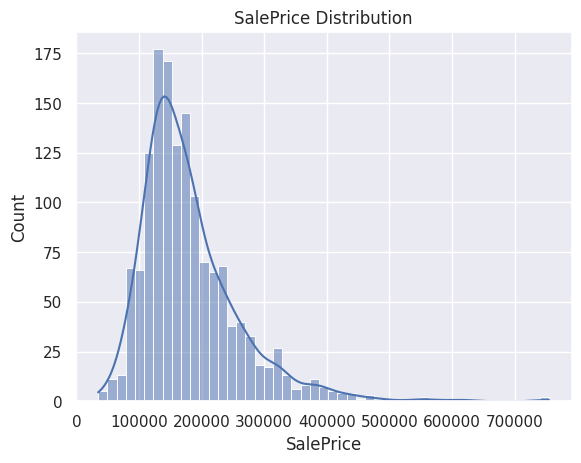

Skewness: 1.882876
Kurtosis: 6.536282


In [ ]:
sns.histplot(df_train['SalePrice'], kde=True)
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()

print("Skewness: %f" % df_train['SalePrice'].skew())
print("Kurtosis: %f" % df_train['SalePrice'].kurt())

## Cell 9: Log-transform `SalePrice`

**What it does:** This cell creates a log-transformed version of `SalePrice` and removes the original `SalePrice` column.

**Libraries used:** `numpy` is used for log calculation, `seaborn` visualises the transformed distribution, and `pandas` creates/removes columns.

**pandas / numpy methods:** `np.log()` converts sale price into log scale. `.drop()` removes the original column.

**Loops / conditions:** This version includes a condition so the cell can be run again without causing an error.

**Why it matters for the business:** The log transformation reduces the impact of extremely expensive houses and helps the model focus on general price patterns.

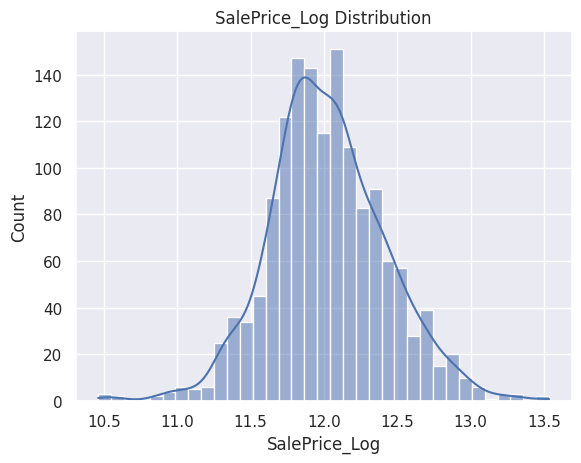

Skewness: 0.121335
Kurtosis: 0.809532


In [ ]:
if 'SalePrice' in df_train.columns:
    df_train['SalePrice_Log'] = np.log(df_train['SalePrice'])

    sns.histplot(df_train['SalePrice_Log'], kde=True)
    plt.title('SalePrice_Log Distribution')
    plt.xlabel('SalePrice_Log')
    plt.ylabel('Count')
    plt.show()

    print("Skewness: %f" % df_train['SalePrice_Log'].skew())
    print("Kurtosis: %f" % df_train['SalePrice_Log'].kurt())

    df_train.drop('SalePrice', axis=1, inplace=True)
else:
    print("SalePrice has already been transformed or is not available.")

## Cell 10: Separate numerical and categorical features

**What it does:** This cell separates the dataset into numerical features and categorical features.

**Libraries used:** `pandas` is used to check the data type of each column.

**pandas / numpy methods:** `.select_dtypes()` selects columns based on their data type. `.columns` returns the selected column names. `len()` counts how many features are in each group.

**Loops / conditions:** There are no explicit loops. The data type selections act as filters.

**Why it matters for the business:** Numerical and categorical features need different preparation. For example, house area is already numerical, but neighbourhood is text and must be transformed before modelling.

In [ ]:
numerical_feats = df_train.select_dtypes(include=[np.number]).columns
print("Number of Numerical features:", len(numerical_feats))

categorical_feats = df_train.select_dtypes(include=['object']).columns
print("Number of Categorical features:", len(categorical_feats))

Number of Numerical features: 38
Number of Categorical features: 43


## Cell 11: Check missing values

**What it does:** This cell checks which columns have missing values and calculates the percentage of missing data.

**Libraries used:** `pandas` is used to check, count, sort and combine missing-value information.

**pandas / numpy methods:** `.isnull()` marks missing values, `.sum()` counts them, `.count()` counts non-missing values, `.sort_values()` sorts the result, `pd.concat()` combines tables, and `.head(20)` shows the first 20 rows.

**Loops / conditions:** There are no loops or conditions.

**Why it matters for the business:** Missing data can reduce reliability. This cell identifies which property features need cleaning before modelling.

In [ ]:
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageQual,81,0.055479
GarageFinish,81,0.055479
GarageType,81,0.055479


## Cell 12: Fill missing categorical values

**What it does:** This cell replaces missing values with `None` for selected categorical columns.

**Libraries used:** `pandas` is used to fill missing values in the DataFrames.

**pandas / numpy methods:** `.fillna('None')` replaces missing values with the text `None`.

**Loops / conditions:** The `for` loop repeats the same replacement for every column in the list. The `if` checks make the cell safer if a column is not present.

**Why it matters for the business:** In some columns, a missing value has meaning. For example, missing `PoolQC` can mean the house does not have a pool.

In [ ]:
cols_fillna =  ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu',
               'GarageQual','GarageCond','GarageFinish','GarageType', 'Electrical',
               'KitchenQual', 'SaleType', 'Functional', 'Exterior2nd', 'Exterior1st',
               'BsmtExposure','BsmtCond','BsmtQual','BsmtFinType1','BsmtFinType2',
               'MSZoning', 'Utilities']

for col in cols_fillna:
   df_train[col].fillna('None',inplace=True)
   df_test[col].fillna('None',inplace=True)


## Cell 13: Fill remaining missing numerical values

**What it does:** This cell fills remaining missing numerical values using the column average and checks whether any missing values remain.

**Libraries used:** `pandas` and `numpy` are used to select numerical columns and fill missing values.

**pandas / numpy methods:** `.select_dtypes()` selects numerical columns, `.fillna()` replaces missing values, `.mean()` calculates the average, and `.isnull().sum().sum()` counts total remaining missing values.

**Loops / conditions:** There are no explicit loops or conditions.

**Why it matters for the business:** Correlation analysis, heatmaps and machine learning models need clean numerical data. This step prevents blank heatmap cells and model errors caused by missing numerical values.

In [ ]:
# Fill remaining missing numerical values only
num_cols_train = df_train.select_dtypes(include=[np.number]).columns
num_cols_test = df_test.select_dtypes(include=[np.number]).columns

df_train[num_cols_train] = df_train[num_cols_train].fillna(df_train[num_cols_train].mean())
df_test[num_cols_test] = df_test[num_cols_test].fillna(df_test[num_cols_test].mean())

print("Missing values in train:", df_train.isnull().sum().sum())
print("Missing values in test:", df_test.isnull().sum().sum())

Missing values in train: 0
Missing values in test: 0


## Cell 14: Check skewness and kurtosis for numerical features

**What it does:** This cell checks the distribution shape of every numerical feature.

**Libraries used:** `pandas` is used to calculate skewness and kurtosis.

**pandas / numpy methods:** `.skew()` measures whether a feature is unevenly distributed, and `.kurt()` measures whether a feature contains many extreme values.

**Loops / conditions:** The `for` loop repeats the same calculation for every numerical column.

**Why it matters for the business:** This helps identify features with extreme values, such as very large land size or living area, that may need transformation before modelling.

In [ ]:
for col in numerical_feats:
    print('{:15}'.format(col),
          'Skewness: {:05.2f}'.format(df_train[col].skew()) ,
          '   ' ,
          'Kurtosis: {:06.2f}'.format(df_train[col].kurt())
         )

Id              Skewness: 00.00     Kurtosis: -01.20
MSSubClass      Skewness: 01.41     Kurtosis: 001.58
LotFrontage     Skewness: 02.38     Kurtosis: 021.85
LotArea         Skewness: 12.21     Kurtosis: 203.24
OverallQual     Skewness: 00.22     Kurtosis: 000.10
OverallCond     Skewness: 00.69     Kurtosis: 001.11
YearBuilt       Skewness: -0.61     Kurtosis: -00.44
YearRemodAdd    Skewness: -0.50     Kurtosis: -01.27
MasVnrArea      Skewness: 02.68     Kurtosis: 010.15
BsmtFinSF1      Skewness: 01.69     Kurtosis: 011.12
BsmtFinSF2      Skewness: 04.26     Kurtosis: 020.11
BsmtUnfSF       Skewness: 00.92     Kurtosis: 000.47
TotalBsmtSF     Skewness: 01.52     Kurtosis: 013.25
1stFlrSF        Skewness: 01.38     Kurtosis: 005.75
2ndFlrSF        Skewness: 00.81     Kurtosis: -00.55
LowQualFinSF    Skewness: 09.01     Kurtosis: 083.23
GrLivArea       Skewness: 01.37     Kurtosis: 004.90
BsmtFullBath    Skewness: 00.60     Kurtosis: -00.84
BsmtHalfBath    Skewness: 04.10     Kurtosis: 

## Cell 15: Log-transform selected property features

**What it does:** This cell creates log-transformed versions of `GrLivArea` and `LotArea` for both training and testing datasets.

**Libraries used:** `numpy` is used for log transformation, and `pandas` is used to create and remove columns.

**pandas / numpy methods:** `np.log()` converts the original values into log scale. `.drop()` removes the original columns after the log versions are created.

**Loops / conditions:** The `for` loop repeats the transformation for both datasets. The `if` checks prevent `KeyError` if the cell is accidentally run more than once.

**Why it matters for the business:** This reduces the effect of very large houses or land areas, making the data more balanced for price prediction.

In [ ]:
for df in [df_train, df_test]:

    if 'GrLivArea' in df.columns:
        df['GrLivArea_Log'] = np.log(df['GrLivArea'])
        df.drop('GrLivArea', inplace=True, axis=1)

    if 'LotArea' in df.columns:
        df['LotArea_Log'] = np.log(df['LotArea'])
        df.drop('LotArea', inplace=True, axis=1)

# Refresh numerical features after transformation
numerical_feats = df_train.select_dtypes(include=[np.number]).columns
print("Number of numerical features after log transformation:", len(numerical_feats))

Number of numerical features after log transformation: 38


## Cell 16: Plot numerical features against `SalePrice_Log`

**What it does:** This cell creates a grid of regression plots to compare each numerical house feature with `SalePrice_Log`. Each plot also shows the Pearson correlation value.

**Libraries used:** `matplotlib` creates the grid, `seaborn` creates regression plots, and `scipy.stats` calculates Pearson correlation.

**pandas / numpy methods:** `.copy()` creates a temporary dataset, `.replace()` changes infinite values into `NaN`, `.dropna()` removes missing values, and `.nunique()` checks whether the feature has enough variation.

**Loops / conditions:** Two loops create the chart grid. Conditions check whether a feature exists and whether the data is clean enough for plotting.

**Why it matters for the business:** This helps identify which house features have stronger relationships with price and are more useful for prediction.

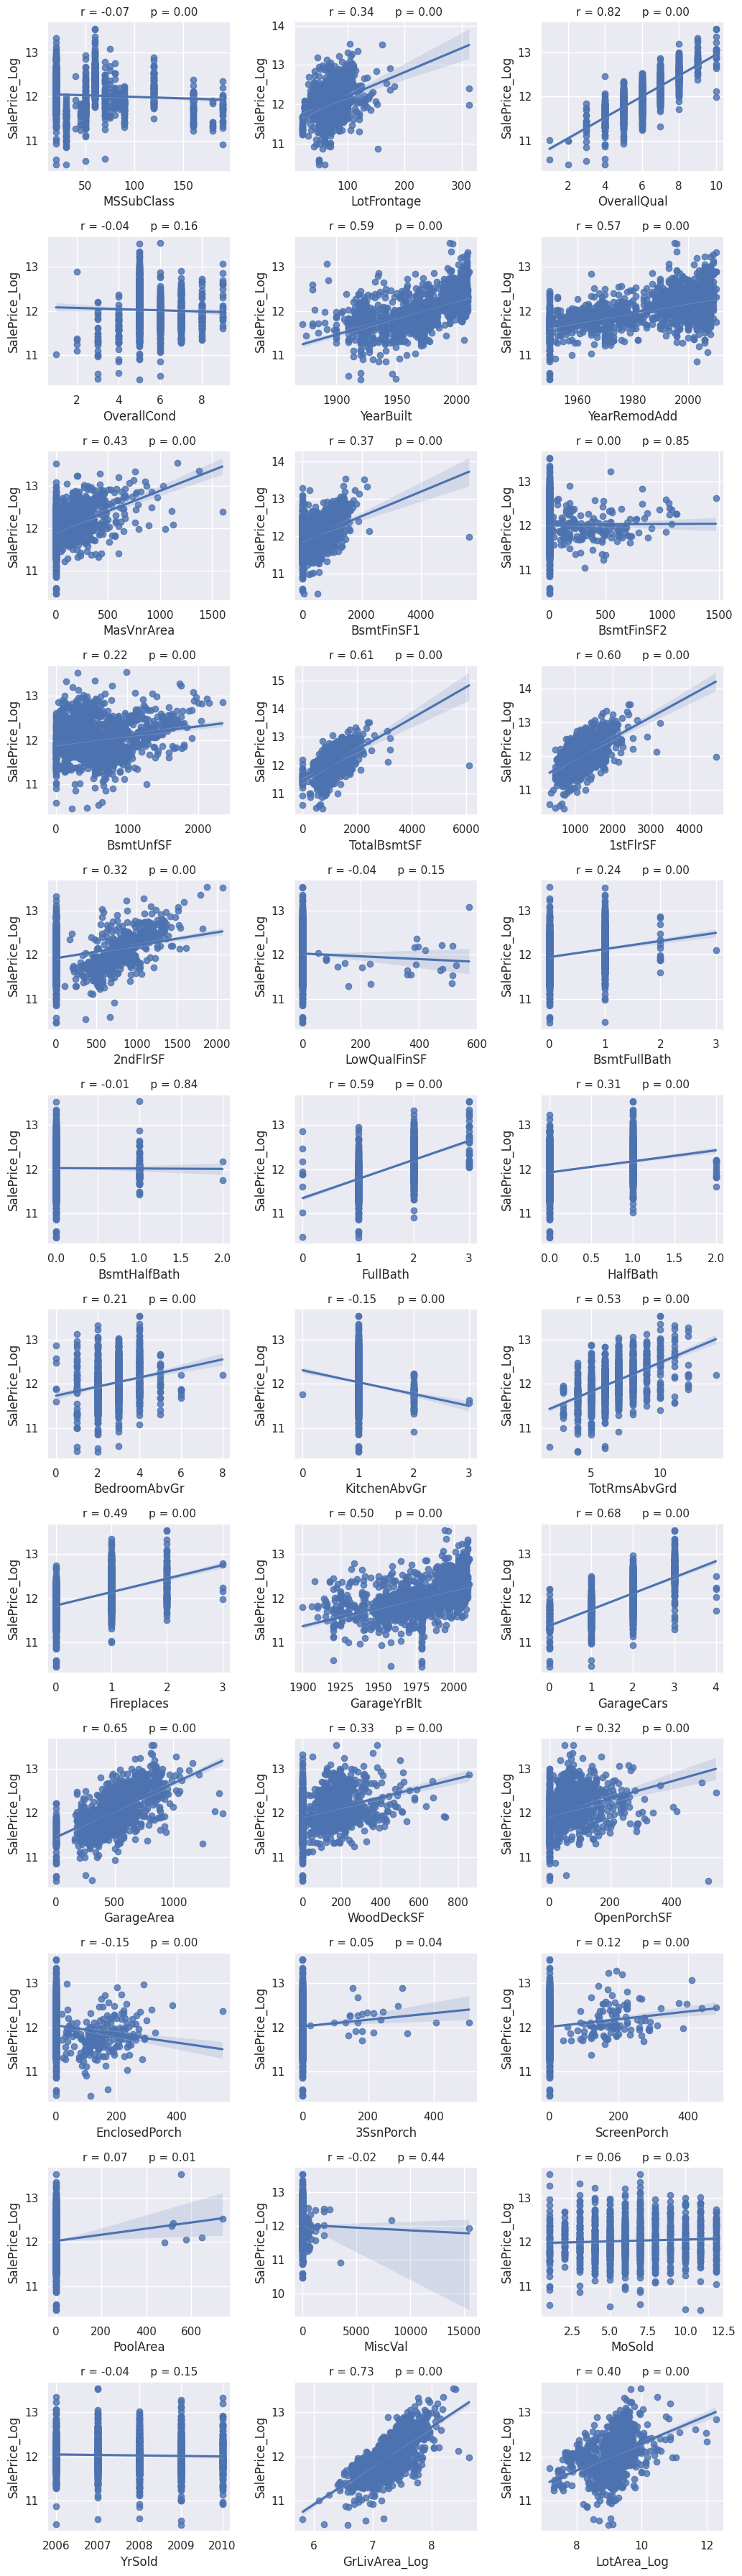

In [ ]:
nr_rows = 12
nr_cols = 3

fig, axs = plt.subplots(nr_rows, nr_cols, figsize=(nr_cols * 3.5, nr_rows * 3))

li_not_plot = ['Id', 'SalePrice', 'SalePrice_Log']
li_plot_num_feats = [c for c in list(numerical_feats) if c not in li_not_plot]

for r in range(0, nr_rows):
    for c in range(0, nr_cols):
        i = r * nr_cols + c

        if i < len(li_plot_num_feats):
            feature = li_plot_num_feats[i]
            plot_data = df_train[[feature, target]].copy()
            plot_data = plot_data.replace([np.inf, -np.inf], np.nan).dropna()

            if len(plot_data) > 1 and plot_data[feature].nunique() > 1:
                sns.regplot(
                    x=plot_data[feature],
                    y=plot_data[target],
                    ax=axs[r][c]
                )
                stp = stats.pearsonr(plot_data[feature], plot_data[target])
                str_title = "r = " + "{0:.2f}".format(stp[0]) + "      p = " + "{0:.2f}".format(stp[1])
                axs[r][c].set_title(str_title, fontsize=11)
            else:
                axs[r][c].set_title(feature + " skipped", fontsize=11)
        else:
            axs[r][c].axis('off')

plt.tight_layout()
plt.show()

## Cell 17: Select correlated features and create correlation heatmap

**What it does:** This cell creates a correlation heatmap for features that have a stronger relationship with `SalePrice_Log`.

**Libraries used:** `pandas` calculates correlations, `numpy` handles numerical cleaning, and `matplotlib`/`seaborn` display the heatmap through the helper function.

**pandas / numpy methods:** `.select_dtypes()` keeps numerical columns only, `.replace()` handles infinite values, `.fillna()` fills missing values, `.corr()` calculates correlation, `.abs()` makes correlations positive, `.sort_values()` orders the correlations, and `.index` returns the selected column names.

**Loops / conditions:** There are no explicit loops. The condition `ser_corr >= min_val_corr` selects features above the minimum correlation threshold.

**Why it matters for the business:** This heatmap helps identify which property features are most strongly connected with sale price (close to 1.00).

Features above correlation limit: ['SalePrice_Log', 'OverallQual', 'GrLivArea_Log', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'TotRmsAbvGrd', 'GarageYrBlt', 'Fireplaces', 'MasVnrArea']


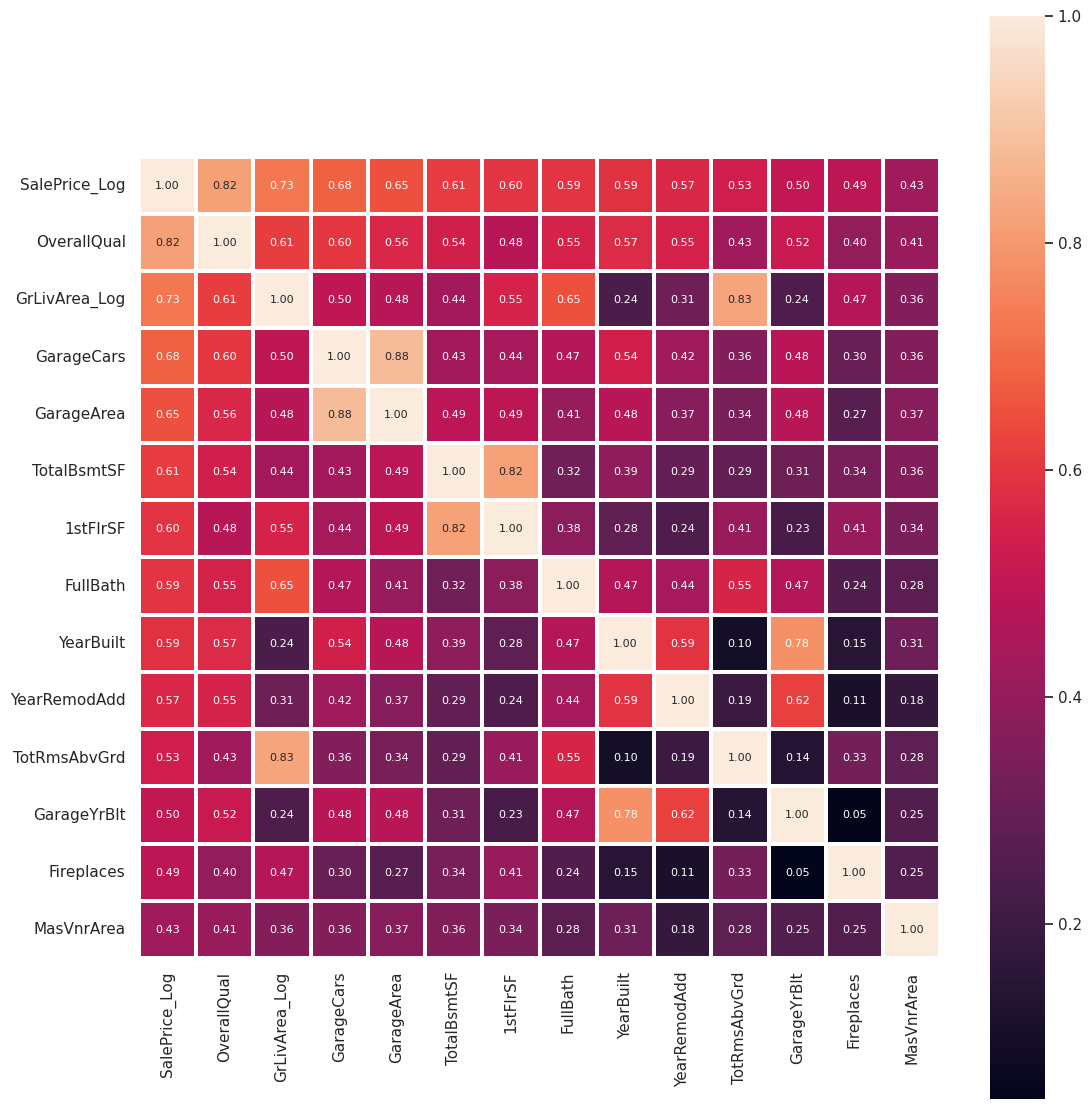

In [ ]:
heatmap_df = df_train.select_dtypes(include=[np.number]).copy()
heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)
heatmap_df = heatmap_df.fillna(heatmap_df.median())

corr_abs = heatmap_df.corr().abs()
ser_corr = corr_abs[target].sort_values(ascending=False)

cols_abv_corr_limit = list(ser_corr[ser_corr >= min_val_corr].index)
cols_bel_corr_limit = list(ser_corr[ser_corr < min_val_corr].index)

nr_feats = len(cols_abv_corr_limit)
print("Features above correlation limit:", cols_abv_corr_limit)

plot_corr_matrix(heatmap_df, nr_feats, target)

## Cell 18: Convert selected categorical features into numbers

**What it does:** This cell changes selected text-based features into numerical features. For example, `MSZoning`, `Neighborhood`, `ExterQual`, `BsmtQual`, `KitchenQual` and `SaleType` are converted into new number columns.

**Libraries used:** `pandas` is used because the code updates `df_train` and `df_test` DataFrames.

**pandas / numpy methods:** `.loc[]` updates rows that match certain conditions, and `.isin()` checks whether a category is inside a list.

**Loops / conditions:** The loop applies the same conversions to both training and testing datasets. The `.loc[]` lines act like conditions.

**Why it matters for the business:** Machine learning models work better with numbers than text. This allows the model to use property information such as neighbourhood, zoning and kitchen quality.

In [ ]:
# 'MSZoning'
msz_catg2 = ['RM', 'RH']
msz_catg3 = ['RL', 'FV']

# Neighborhood
nbhd_catg2 = ['Blmngtn', 'ClearCr', 'CollgCr', 'Crawfor', 'Gilbert',
              'NWAmes', 'Somerst', 'Timber', 'Veenker']
nbhd_catg3 = ['NoRidge', 'NridgHt', 'StoneBr']

# Condition2
cond2_catg2 = ['Norm', 'RRAe']
cond2_catg3 = ['PosA', 'PosN']

# SaleType
SlTy_catg1 = ['Oth']
SlTy_catg3 = ['CWD']
SlTy_catg4 = ['New', 'Con']

for df in [df_train, df_test]:
    df['MSZ_num'] = 1
    df.loc[(df['MSZoning'].isin(msz_catg2)), 'MSZ_num'] = 2
    df.loc[(df['MSZoning'].isin(msz_catg3)), 'MSZ_num'] = 3

    df['NbHd_num'] = 1
    df.loc[(df['Neighborhood'].isin(nbhd_catg2)), 'NbHd_num'] = 2
    df.loc[(df['Neighborhood'].isin(nbhd_catg3)), 'NbHd_num'] = 3

    df['Cond2_num'] = 1
    df.loc[(df['Condition2'].isin(cond2_catg2)), 'Cond2_num'] = 2
    df.loc[(df['Condition2'].isin(cond2_catg3)), 'Cond2_num'] = 3

    df['Mas_num'] = 1
    df.loc[(df['MasVnrType'] == 'Stone'), 'Mas_num'] = 2

    df['ExtQ_num'] = 1
    df.loc[(df['ExterQual'] == 'TA'), 'ExtQ_num'] = 2
    df.loc[(df['ExterQual'] == 'Gd'), 'ExtQ_num'] = 3
    df.loc[(df['ExterQual'] == 'Ex'), 'ExtQ_num'] = 4

    df['BsQ_num'] = 1
    df.loc[(df['BsmtQual'] == 'Gd'), 'BsQ_num'] = 2
    df.loc[(df['BsmtQual'] == 'Ex'), 'BsQ_num'] = 3

    df['CA_num'] = 0
    df.loc[(df['CentralAir'] == 'Y'), 'CA_num'] = 1

    df['Elc_num'] = 1
    df.loc[(df['Electrical'] == 'SBrkr'), 'Elc_num'] = 2

    df['KiQ_num'] = 1
    df.loc[(df['KitchenQual'] == 'TA'), 'KiQ_num'] = 2
    df.loc[(df['KitchenQual'] == 'Gd'), 'KiQ_num'] = 3
    df.loc[(df['KitchenQual'] == 'Ex'), 'KiQ_num'] = 4

    df['SlTy_num'] = 2
    df.loc[(df['SaleType'].isin(SlTy_catg1)), 'SlTy_num'] = 1
    df.loc[(df['SaleType'].isin(SlTy_catg3)), 'SlTy_num'] = 3
    df.loc[(df['SaleType'].isin(SlTy_catg4)), 'SlTy_num'] = 4

## Cell 19: Remove similar highly correlated features

**What it does:** This cell checks the strongest features related to `SalePrice_Log`, then removes some features that are too similar to other features.

**Libraries used:** `pandas` is used to calculate correlation and select the strongest features.

**pandas / numpy methods:** `.select_dtypes()` keeps numerical columns, `.corr()` calculates correlation, `.abs()` changes values to positive numbers, `.nlargest()` selects strongest relationships, and `.remove()` removes repeated features from the list.

**Loops / conditions:** The `if drop_similar == 1` condition checks whether similar features should be removed. The `for` loop checks each repeated feature, and `if col in cols` prevents errors.

**Why it matters for the business:** Some features give similar information, such as `GarageArea` and `GarageCars`. Removing repeated information helps make the model simpler and easier to interpret.

In [ ]:
numeric_df = df_train.select_dtypes(include=[np.number]).copy()
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.fillna(numeric_df.median())

corr = numeric_df.corr()
corr_abs = corr.abs()

nr_all_cols = len(numeric_df.columns)
cols = corr_abs.nlargest(nr_all_cols, target)[target].index
cols = list(cols)

if drop_similar == 1:
    for col in ['GarageArea', '1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt']:
        if col in cols:
            cols.remove(col)

cols = list(cols)
print(cols)

['SalePrice_Log', 'OverallQual', 'GrLivArea_Log', 'NbHd_num', 'GarageCars', 'ExtQ_num', 'KiQ_num', 'BsQ_num', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'MasVnrArea', 'MSZ_num', 'LotArea_Log', 'BsmtFinSF1', 'CA_num', 'LotFrontage', 'SlTy_num', 'WoodDeckSF', 'OpenPorchSF', '2ndFlrSF', 'HalfBath', 'Mas_num', 'Elc_num', 'BsmtFullBath', 'BsmtUnfSF', 'BedroomAbvGr', 'EnclosedPorch', 'KitchenAbvGr', 'ScreenPorch', 'Cond2_num', 'MSSubClass', 'PoolArea', 'MoSold', '3SsnPorch', 'LowQualFinSF', 'YrSold', 'OverallCond', 'MiscVal', 'Id', 'BsmtHalfBath', 'BsmtFinSF2']


## Cell 20: Create final machine learning datasets

**What it does:** This cell creates the final training and testing datasets used for machine learning. It also checks and fixes any missing or infinite values before the model is trained.

**Libraries used:** `SimpleImputer` from Scikit-learn fills missing values. `pandas` manages the datasets. `numpy` identifies infinite values.

**pandas / numpy methods:** `.copy()` creates a separate copy, `.replace()` changes infinite values into missing values, `.isnull().sum()` checks missing values, and `pd.DataFrame()` converts the imputed result back into a DataFrame.

**Loops / conditions:** There are no loops or if/else conditions. The code checks for missing values by printing columns where missing values are greater than zero.

**Why it matters for the business:** Random Forest cannot work properly if the input data contains missing or infinite values. This step ensures the model can train successfully.

In [ ]:
from sklearn.impute import SimpleImputer

feats = cols.copy()
if 'SalePrice_Log' in feats:
    feats.remove('SalePrice_Log')

# Keep only features that exist in both train and test
feats = [f for f in feats if f in df_train.columns and f in df_test.columns]

print("Number of final features:", len(feats))
print(feats)

df_train_ml = df_train[feats].copy()
df_test_ml = df_test[feats].copy()

# Replace infinite values with NaN
df_train_ml = df_train_ml.replace([np.inf, -np.inf], np.nan)
df_test_ml = df_test_ml.replace([np.inf, -np.inf], np.nan)

print("Missing values before fixing:")
print(df_train_ml.isnull().sum()[df_train_ml.isnull().sum() > 0])

imputer = SimpleImputer(strategy='median')

df_train_ml = pd.DataFrame(
    imputer.fit_transform(df_train_ml),
    columns=df_train_ml.columns,
    index=df_train_ml.index
)

df_test_ml = pd.DataFrame(
    imputer.transform(df_test_ml),
    columns=df_test_ml.columns,
    index=df_test_ml.index
)

y = df_train[target]

print("Missing values after fixing:")
print("df_train_ml:", df_train_ml.isnull().sum().sum())
print("df_test_ml:", df_test_ml.isnull().sum().sum())

Number of final features: 43
['OverallQual', 'GrLivArea_Log', 'NbHd_num', 'GarageCars', 'ExtQ_num', 'KiQ_num', 'BsQ_num', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'MasVnrArea', 'MSZ_num', 'LotArea_Log', 'BsmtFinSF1', 'CA_num', 'LotFrontage', 'SlTy_num', 'WoodDeckSF', 'OpenPorchSF', '2ndFlrSF', 'HalfBath', 'Mas_num', 'Elc_num', 'BsmtFullBath', 'BsmtUnfSF', 'BedroomAbvGr', 'EnclosedPorch', 'KitchenAbvGr', 'ScreenPorch', 'Cond2_num', 'MSSubClass', 'PoolArea', 'MoSold', '3SsnPorch', 'LowQualFinSF', 'YrSold', 'OverallCond', 'MiscVal', 'Id', 'BsmtHalfBath', 'BsmtFinSF2']
Missing values before fixing:
Series([], dtype: int64)
Missing values after fixing:
df_train_ml: 0
df_test_ml: 0


## Cell 21: Standardise the data

**What it does:** This cell standardises selected features so they are on a similar scale.

**Libraries used:** `StandardScaler` from Scikit-learn.

**pandas / numpy methods:** No central pandas or numpy methods are used in this cell.

**Loops / conditions:** There are no loops or conditions.

**Why it matters for the business:** Scaling helps some models work more fairly because large-number features do not dominate smaller-number features. Random Forest does not require scaling, but scaling is useful if other models are compared.

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df_train_ml_sc = sc.fit_transform(df_train_ml)
df_test_ml_sc = sc.transform(df_test_ml)

## Cell 22: Model training example — Random Forest

**What it does:** This cell trains a Random Forest regression model and uses `GridSearchCV` to test different model settings.

**Libraries used:** `RandomForestRegressor` is the regression model. `GridSearchCV` tests combinations of settings and chooses the best one.

**pandas / numpy methods:** `.copy()` creates a copy of the final training feature dataset. `get_best_score()` uses NumPy earlier to calculate RMSE.

**Loops / conditions:** There is no visible loop, but `GridSearchCV` automatically repeats training many times using the values in `param_grid` and cross-validation.

**Why it matters for the business:** A better-tuned model can improve house price prediction accuracy and support more reliable property pricing decisions.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

score_calc = 'neg_mean_squared_error'
X = df_train_ml.copy()
y = df_train[target]

param_grid = {
    'min_samples_split': [3, 4, 6, 10],
    'n_estimators': [70, 100],
    'random_state': [5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=nr_cv,
    refit=True,
    verbose=1,
    scoring=score_calc
)

grid_rf.fit(X, y)
sc_rf = get_best_score(grid_rf)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
0.14222468529348026
{'min_samples_split': 4, 'n_estimators': 100, 'random_state': 5}
RandomForestRegressor(min_samples_split=4, random_state=5)


## Cell 23: Output and create prediction file

**What it does:** This cell uses the trained Random Forest model to predict house prices for the test dataset, then creates `submission.csv`.

**Libraries used:** `pandas` creates the submission DataFrame, and `numpy` converts predicted log prices back to normal prices using `np.exp()`.

**pandas / numpy methods:** `.copy()` creates a separate copy of the test features, `pd.DataFrame()` creates the output table, `np.exp()` reverses the log transformation, `.to_csv()` saves the file, and `.head(10)` displays the first 10 rows.

**Loops / conditions:** There are no loops. The condition `if use_logvals == 1` decides whether predictions need to be converted from log values back into normal dollar prices.

**Why it matters for the business:** This produces the final predicted house prices that can support faster property valuation, comparison and pricing decisions.

In [ ]:
X_test = df_test_ml.copy()
id_test = df_test['Id']
pred_rf = grid_rf.predict(X_test)

sub_rf = pd.DataFrame()
sub_rf['Id'] = id_test
sub_rf['SalePrice'] = pred_rf

if use_logvals == 1:
    sub_rf['SalePrice'] = np.exp(sub_rf['SalePrice'])

sub_rf.to_csv('submission.csv', index=False)
sub_rf.head(10)

,Id,SalePrice
0,1461,123425.993159
1,1462,154558.072723
2,1463,190751.805426
3,1464,181898.665590
4,1465,190716.289975
5,1466,185410.875841
6,1467,163208.192659
7,1468,177881.358645
8,1469,181807.481928
9,1470,114161.271647


##RMSE Check

Model comparison based on prediction error:


,Model,RMSE_Log,MAE_Log,RMSE_Price,MAE_Price,R2_Score
4,SGD,0.134001,0.096042,27260.281151,16687.520836,0.903779
2,Lasso,0.134492,0.093588,28811.853206,16675.473995,0.903072
1,Ridge,0.135214,0.094898,28956.912628,16882.817308,0.902028
0,Linear,0.135214,0.094898,28957.055222,16882.875931,0.902028
3,ElaNet,0.137261,0.093556,29693.469013,16798.339299,0.899040
6,RF,0.145650,0.098725,30025.095120,17705.503575,0.886322
7,KNN,0.182923,0.124702,39122.308994,22575.364364,0.820695
5,DTr,0.195398,0.131166,39416.722186,23498.509761,0.795404


Best model: SGD
Best RMSE_Log: 0.1340006177155061
Best RMSE_Price: 27260.28115128214
Best MAE_Price: 16687.520836415395
Best R2 Score: 0.9037788595556916


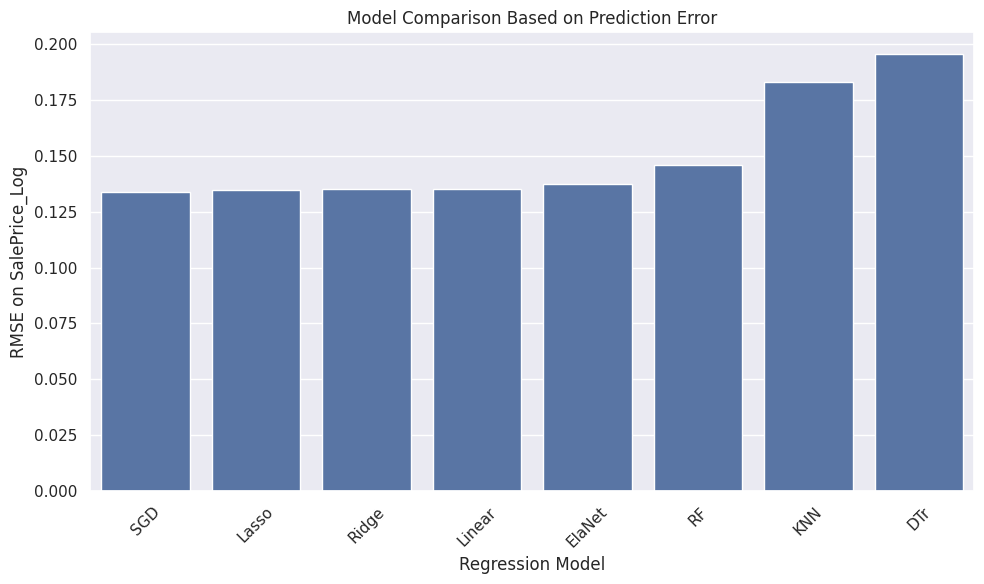

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor


# Features and target
X = df_train_ml.copy()
y = df_train[target]   # SalePrice_Log

# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define models directly
models = {
    'Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0.01))
    ]),

    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.001, max_iter=10000))
    ]),

    'ElaNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.1, l1_ratio=0.04, max_iter=100000))
    ]),

    'SGD': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SGDRegressor(max_iter=10000, alpha=1e-5, random_state=42))
    ]),

    'DTr': DecisionTreeRegressor(
        max_depth=8,
        min_samples_split=20,
        random_state=5
    ),

    'RF': RandomForestRegressor(
        n_estimators=100,
        min_samples_split=4,
        random_state=5
    ),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=5, weights='distance'))
    ]),

    'GPR': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianProcessRegressor(random_state=5, alpha=5e-9))
    ])
}

# Train, predict, and compare error
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred_log = model.predict(X_valid)

    rmse_log = np.sqrt(mean_squared_error(y_valid, y_pred_log))
    mae_log = mean_absolute_error(y_valid, y_pred_log)
    r2 = r2_score(y_valid, y_pred_log)

    # Convert log values back to normal house prices
    y_valid_price = np.exp(y_valid)
    y_pred_price = np.exp(y_pred_log)

    rmse_price = np.sqrt(mean_squared_error(y_valid_price, y_pred_price))
    mae_price = mean_absolute_error(y_valid_price, y_pred_price)

    results.append({
        'Model': name,
        'RMSE_Log': rmse_log,
        'MAE_Log': mae_log,
        'RMSE_Price': rmse_price,
        'MAE_Price': mae_price,
        'R2_Score': r2
    })

# Create results table
results_df = pd.DataFrame(results)

# Sort models from best to worst
results_df = results_df.sort_values(by='RMSE_Log', ascending=True)

print("Model comparison based on prediction error:")
display(results_df)

# Best model
best_model = results_df.iloc[0]

print("Best model:", best_model['Model'])
print("Best RMSE_Log:", best_model['RMSE_Log'])
print("Best RMSE_Price:", best_model['RMSE_Price'])
print("Best MAE_Price:", best_model['MAE_Price'])
print("Best R2 Score:", best_model['R2_Score'])

# Plot comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSE_Log', data=results_df)
plt.title('Model Comparison Based on Prediction Error')
plt.xlabel('Regression Model')
plt.ylabel('RMSE on SalePrice_Log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()